# Muon Track Reconstruction with a Kalman Filter (Toy Model)

## Overview

This notebook demonstrates a simplified track reconstruction workflow inspired by high-energy physics experiments such as the ATLAS Collaboration at CERN.

Using simulated events generated with Delphes, we select truth-level muons from \(Z \to \mu^+\mu^-\) decays and construct synthetic detector measurements. These measurements are then used to reconstruct the muon trajectory with a Kalman filter.

The goal is to illustrate how sequential state estimation can recover the underlying particle trajectory from noisy detector data.

---

## Detector Modeling

Delphes does not provide per-layer detector hits in its standard output. Therefore, we construct a simplified detector model:

- The detector is represented by a set of cylindrical (barrel) layers at fixed radii.
- For each truth muon, the trajectory is propagated as a straight line from its production vertex.
- The intersection of the trajectory with each cylindrical layer is computed analytically.
- The resulting hit positions are smeared with Gaussian noise to emulate detector resolution.

This produces a set of synthetic measurements:
$$
(x_{\text{meas}}, y_{\text{meas}}, z_{\text{meas}})
$$

---

## Track Parameterization

The particle trajectory is modeled as a straight line in 3D:

$$
x(z) = x_0 + t_x (z - z_0), \quad
y(z) = y_0 + t_y (z - z_0)
$$

The Kalman filter state vector is defined as:

$$
\mathbf{x} =
\begin{bmatrix}
x \\
y \\
t_x \\
t_y
\end{bmatrix}
$$

where:
- \(x, y\): transverse position
- \(t_x = dx/dz\), \(t_y = dy/dz\): track slopes

In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [35]:
hits_df = pd.read_csv("hits_df.csv")
hits_df

,event_id,muon_id,hit_id,r_layer,x_true,y_true,z_true,x_meas,y_meas,z_meas,phi_true,phi_meas
0,0,0,0,300.0,-16.090726,-299.568170,-2.419227,-15.786009,-300.608154,-0.918324,-1.624458,-1.623262
1,0,0,1,500.0,-26.817877,-499.280283,-4.032045,-25.877312,-501.231319,-6.636404,-1.624458,-1.622378
2,0,0,2,700.0,-37.545028,-698.992397,-5.644862,-37.417188,-699.308639,-5.678465,-1.624458,-1.624251
3,0,0,3,900.0,-48.272179,-898.704510,-7.257680,-49.125223,-897.825112,-5.702096,-1.624458,-1.625458
4,0,0,4,1100.0,-58.999330,-1098.416624,-8.870498,-58.933299,-1097.289382,-7.935479,-1.624458,-1.624453
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,9999,1,0,300.0,101.662403,282.249457,-1372.719613,102.492509,283.569870,-1373.702795,1.225076,1.223970
99996,9999,1,1,500.0,169.437338,470.415761,-2287.866021,170.154812,469.515534,-2286.520623,1.225076,1.223113
99997,9999,1,2,700.0,237.212274,658.582066,-3203.012429,237.605325,659.333665,-3200.756605,1.225076,1.224912
99998,9999,1,3,900.0,304.987209,846.748370,-4118.158838,305.881961,847.251735,-4118.820023,1.225076,1.224331


In [36]:
len(hits_df["event_id"])

100000

---

## Initialization

The initial state is obtained from the first two detector hits:

- position from the first hit,
- slopes estimated from the difference between the first two hits.

A large initial covariance is used to reflect the uncertainty of this estimate.

---

## Kalman Filter Formulation

The Kalman filter estimates the track parameters sequentially as hits are processed layer by layer.

### Prediction step

The state is propagated between detector layers:

$$
\mathbf{x}_{k|k-1} = F_k \mathbf{x}_{k-1|k-1}
$$

with:

$$
F_k =
\begin{bmatrix}
1 & 0 & \Delta z & 0 \\
0 & 1 & 0 & \Delta z \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

The covariance evolves as:

$$
P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q
$$

where \(Q\) represents process noise.

---

### Measurement step

Each detector layer provides a measurement of position:

$$
\mathbf{z}_k =
\begin{bmatrix}
x_{\text{meas}} \\
y_{\text{meas}}
\end{bmatrix}
$$

with measurement model:

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
$$

and covariance:

$$
R =
\begin{bmatrix}
\sigma_x^2 & 0 \\
0 & \sigma_y^2
\end{bmatrix}
$$

---

### Update step

The filter combines prediction and measurement using:

$$
\mathbf{x}_{k|k} = \mathbf{x}_{k|k-1} + K_k (\mathbf{z}_k - H \mathbf{x}_{k|k-1})
$$

$$
K_k = P_{k|k-1} H^T (H P_{k|k-1} H^T + R)^{-1}
$$

This step corrects both the estimated position and the track direction.

---


In [37]:
def kalman_fit_track(track_df, sigma_x=1.0, sigma_y=1.0):
    track_df = track_df.sort_values("z_meas").reset_index(drop=True)

    if len(track_df) < 2:
        return None
    
    # Measurement covariance
    R = np.array(
        [
            [sigma_x**2, 0.0],
            [0.0, sigma_y**2]
        ]
    )

    # Measurement Matrix
    H = np.array(
        [
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0]
        ]
    )

    #Initial state from the first two hits
    x1, y1, z1 = track_df.loc[0, ["x_meas", "y_meas", "z_meas"]]
    x2, y2, z2 = track_df.loc[1, ["x_meas", "y_meas", "z_meas"]]

    dz0 = z2 - z1

    if abs(dz0) < 1e-9:
        return None
    
    tx0 = (x2 - x1) / dz0
    ty0 = (y2 - y1) / dz0

    x_filt = np.array(
        [
            [x1], [y1], [tx0], [ty0]
        ]
    )

    #initial covariance
    P_filt = np.array([
        [10.0, 0.0, 0.0, 0.0],
        [0.0, 10.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])

    fitted_states = []
    fitted_covs = []

    fitted_states.append({
        "z": z1,
        "x_fit": x_filt[0, 0],
        "y_fit": x_filt[1, 0],
        "tx_fit": x_filt[2, 0],
        "ty_fit": x_filt[3, 0],
    })

    fitted_covs.append(P_filt.copy())

    z_prev = z1

    for k in range(1, len(track_df)):
        x_meas, y_meas, z_meas = track_df.loc[k, ["x_meas", "y_meas", "z_meas"]]
        dz = z_meas - z_prev

        #State propagation
        F = np.array([
            [1.0, 0.0, dz, 0.0],
            [0.0, 1.0, 0.0, dz],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

        #Process noise
        Q = np.array([
            [0.05, 0.0, 0.0, 0.0],
            [0.0, 0.05, 0.0, 0.0],
            [0.0, 0.0, 0.001, 0.0],
            [0.0, 0.0, 0.0, 0.001]
        ])

        # Predict
        x_pred = F @ x_filt
        P_pred = F @ P_filt @ F.T + Q
        
        #Measurement
        z_k = np.array([
            [x_meas], [y_meas]
        ])

        #Innovation
        y_k = z_k - H @ x_pred
        S_k = H @ P_pred @ H.T + R
        K_k = P_pred @ H.T @ np.linalg.inv(S_k)

        #Update
        x_filt = x_pred + K_k @ y_k
        P_filt = (np.eye(4) - K_k @ H) @ P_pred

        fitted_states.append({
            "z": z_meas,
            "x_fit": x_filt[0, 0],
            "y_fit": x_filt[1, 0],
            "tx_fit": x_filt[2, 0],
            "ty_fit": x_filt[3, 0],
        })
        fitted_covs.append(P_filt.copy())

        z_prev = z_meas

    return fitted_states, fitted_covs

In [38]:
# pick one track
track_df = hits_df[(hits_df["event_id"] == 0) & (hits_df["muon_id"] == 0)].copy()

result = kalman_fit_track(track_df, sigma_x=1.0, sigma_y=1.0)

if result is not None:
    fitted_states, fitted_covs = result
    fit_df = pd.DataFrame(fitted_states)
    print(fit_df)

          z      x_fit        y_fit     tx_fit      ty_fit
0 -7.935479 -58.933299 -1097.289382  25.445772  458.832399
1 -6.636404 -25.877312  -501.231319  25.445772  458.832399
2 -5.702096 -33.022965  -615.214479  10.737275  200.683655
3 -5.678465 -34.719072  -647.739467   9.856082  183.841389
4 -0.918324 -13.935514  -265.693598   4.899514   90.322431


In [39]:
fit_df = pd.DataFrame(fitted_states)

track_plot_df = track_df.sort_values("z_meas").reset_index(drop=True).copy()
track_plot_df = pd.concat([track_plot_df, fit_df[["x_fit", "y_fit", "tx_fit", "ty_fit"]]], axis=1)

print(track_plot_df)

   event_id  muon_id  hit_id  r_layer     x_true       y_true    z_true  \
0         0        0       4   1100.0 -58.999330 -1098.416624 -8.870498   
1         0        0       1    500.0 -26.817877  -499.280283 -4.032045   
2         0        0       3    900.0 -48.272179  -898.704510 -7.257680   
3         0        0       2    700.0 -37.545028  -698.992397 -5.644862   
4         0        0       0    300.0 -16.090726  -299.568170 -2.419227   

      x_meas       y_meas    z_meas  phi_true  phi_meas      x_fit  \
0 -58.933299 -1097.289382 -7.935479 -1.624458 -1.624453 -58.933299   
1 -25.877312  -501.231319 -6.636404 -1.624458 -1.622378 -25.877312   
2 -49.125223  -897.825112 -5.702096 -1.624458 -1.625458 -33.022965   
3 -37.417188  -699.308639 -5.678465 -1.624458 -1.624251 -34.719072   
4 -15.786009  -300.608154 -0.918324 -1.624458 -1.623262 -13.935514   

         y_fit     tx_fit      ty_fit  
0 -1097.289382  25.445772  458.832399  
1  -501.231319  25.445772  458.832399  
2  -615.

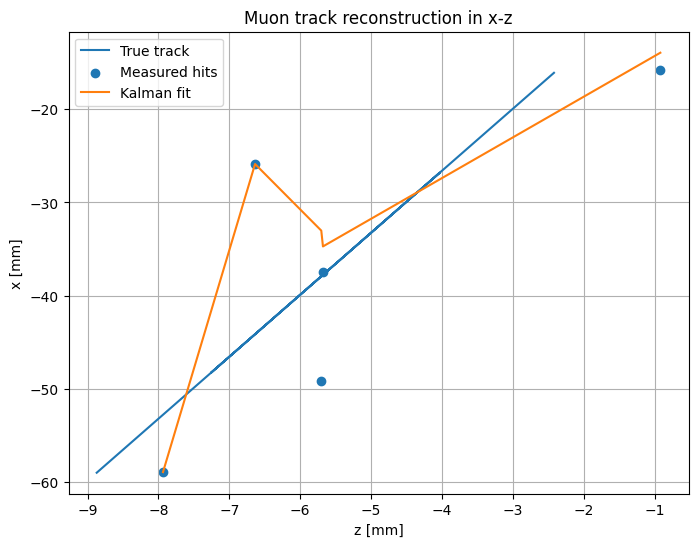

In [41]:
#Plotting
plt.figure(figsize=(8, 6))
plt.plot(track_plot_df["z_true"], track_plot_df["x_true"], label="True track")
plt.scatter(track_plot_df["z_meas"], track_plot_df["x_meas"], label="Measured hits")
plt.plot(track_plot_df["z_meas"], track_plot_df["x_fit"], label="Kalman fit")
plt.xlabel("z [mm]")
plt.ylabel("x [mm]")
plt.title("Muon track reconstruction in x-z")
plt.legend()
plt.grid(True)
plt.show()

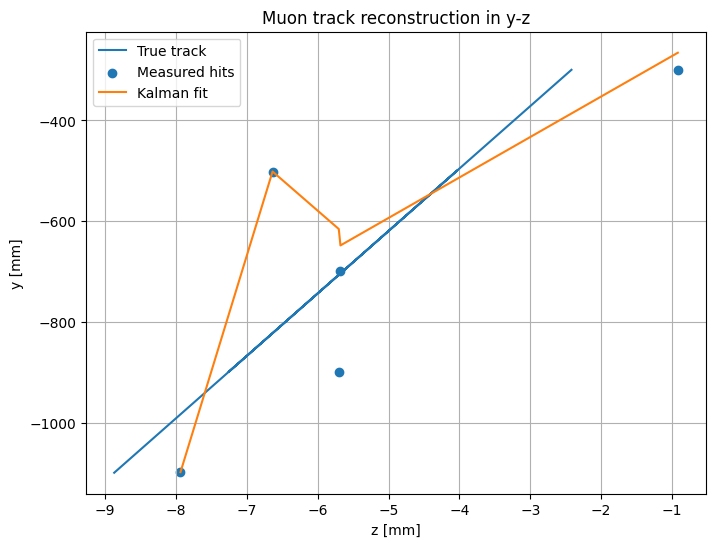

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(track_plot_df["z_true"], track_plot_df["y_true"], label="True track")
plt.scatter(track_plot_df["z_meas"], track_plot_df["y_meas"], label="Measured hits")
plt.plot(track_plot_df["z_meas"], track_plot_df["y_fit"], label="Kalman fit")
plt.xlabel("z [mm]")
plt.ylabel("y [mm]")
plt.title("Muon track reconstruction in y-z")
plt.legend()
plt.grid(True)
plt.show()


## Limitations and Next Steps

This is a simplified model:

- Straight-line propagation (no magnetic field), next step: add the momentum information to propagate in the magnetic field
- Noise modeling
- Fix the ordering of the z_meas

Despite these approximations, the structure of the algorithm closely follows real track reconstruction methods used in modern particle detectors.